### To monitor the status of ambient air quality, The Central Pollution Control Board
(CPCB), India, operates a vast network of monitoring stations spread across the country.
Parameters regularly monitored include sulfur dioxide (SO2), oxides of nitrogen as
nitrogen dioxide (NO2), ozone, and fine particulate matter (PM2.5). Based on trends over
the years, air quality in the national capital of Delhi has emerged as a matter of public
Figure 8-3. Average box office monthly revenue in 2018 (France)
Chapter 8 Data Analysis Case Studies

289
concern. A stepwise analysis of daily air quality data follows to demonstrate how data
analysis could assist in planning interventions as part of air quality management.
Note: The name of the dataset used for this case study is: “NSIT Dwarka.csv”. Please
refer to the technical description section for details on how to import this dataset.

Questions that we want to answer through our analysis:
1. Yearly averages: Out of the four pollutants - SO2, NO2, ozone, and
PM2.5 - which have yearly average levels that regularly surpass the
prescribed annual standards?
2. Daily standards: For the pollutants of concern, on how many days
in each year are the daily standards exceeded?
3. Temporal variation: Which are the months where the pollution
levels exceed critical levels on most days?

In [57]:
import sys
print(sys.executable)

/Users/amanverma/My PC/Coding/Github/Data-Analysis-Case-Studies/venv/bin/python


In [58]:
## Reading Data from github
import pandas as pd
import numpy as np
data = pd.read_csv('NSIT Dwarka.csv')
data.head()

,From Date,To Date,PM2.5,SO2,Ozone,NO2
0,01-01-2014 00:00,02-01-2014 00:00,NaN,22.70,8.63,5.59
1,02-01-2014 00:00,03-01-2014 00:00,NaN,8.72,8.43,3.68
2,03-01-2014 00:00,04-01-2014 00:00,NaN,13.83,9.77,3.83
3,04-01-2014 00:00,05-01-2014 00:00,NaN,27.64,6.83,9.64
4,05-01-2014 00:00,06-01-2014 00:00,NaN,37.17,7.34,11.06


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   From Date  2191 non-null   object 
 1   To Date    2191 non-null   object 
 2   PM2.5      1630 non-null   float64
 3   SO2        2108 non-null   float64
 4   Ozone      2086 non-null   float64
 5   NO2        2087 non-null   float64
dtypes: float64(4), object(2)
memory usage: 102.9+ KB


In [60]:
data.shape

(2192, 6)

In [61]:
data.describe()


,PM2.5,SO2,Ozone,NO2
count,1630.000000,2108.000000,2086.000000,2087.000000
mean,119.154319,9.851157,29.903600,30.419794
std,81.114285,7.896505,19.171954,16.471205
min,1.470000,0.430000,0.800000,1.330000
25%,64.427500,4.780000,16.892500,20.265000
50%,101.295000,7.800000,26.070000,28.020000
75%,145.157500,12.442500,38.607500,37.925000
max,982.690000,122.640000,179.830000,285.530000


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   From Date  2191 non-null   object 
 1   To Date    2191 non-null   object 
 2   PM2.5      1630 non-null   float64
 3   SO2        2108 non-null   float64
 4   Ozone      2086 non-null   float64
 5   NO2        2087 non-null   float64
dtypes: float64(4), object(2)
memory usage: 102.9+ KB


In [63]:
data.isna().sum()

From Date      1
To Date        1
PM2.5        562
SO2           84
Ozone        106
NO2          105
dtype: int64

In [64]:
data = data.replace('None', np.nan)

In [65]:
data.isna().sum()


From Date      1
To Date        1
PM2.5        562
SO2           84
Ozone        106
NO2          105
dtype: int64

In [66]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   From Date  2191 non-null   object 
 1   To Date    2191 non-null   object 
 2   PM2.5      1630 non-null   float64
 3   SO2        2108 non-null   float64
 4   Ozone      2086 non-null   float64
 5   NO2        2087 non-null   float64
dtypes: float64(4), object(2)
memory usage: 102.9+ KB


In [67]:
data.dtypes

From Date     object
To Date       object
PM2.5        float64
SO2          float64
Ozone        float64
NO2          float64
dtype: object

In [68]:
data.nunique()

From Date    2191
To Date      2191
PM2.5        1559
SO2          1265
Ozone        1716
NO2          1673
dtype: int64

In [69]:
data.isnull().sum()

From Date      1
To Date        1
PM2.5        562
SO2           84
Ozone        106
NO2          105
dtype: int64

In [70]:
data.notnull().sum()

From Date    2191
To Date      2191
PM2.5        1630
SO2          2108
Ozone        2086
NO2          2087
dtype: int64

In [71]:
## Data Cleaning and Preprocessing 
data['From Date'] = pd.to_datetime(data['From Date'], errors='coerce') # Convert 'From Date' to datetime, coercing errors to NaT
data['To Date'] = pd.to_datetime(data['To Date'], errors='coerce')
data['SO2'] = pd.to_numeric(data['SO2'], errors='coerce') # Convert 'SO2' to numeric, coercing errors to NaN
data['NO2'] = pd.to_numeric(data['NO2'], errors='coerce')
data['PM2.5'] = pd.to_numeric(data['PM2.5'], errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   From Date  864 non-null    datetime64[ns]
 1   To Date    864 non-null    datetime64[ns]
 2   PM2.5      1630 non-null   float64       
 3   SO2        2108 non-null   float64       
 4   Ozone      2086 non-null   float64       
 5   NO2        2087 non-null   float64       
dtypes: datetime64[ns](2), float64(4)
memory usage: 102.9 KB


In [72]:
data['Year'] = data['From Date'].dt.year
data['Year'].value_counts()

Year
2014.0    144
2015.0    144
2016.0    144
2017.0    144
2018.0    144
2019.0    144
Name: count, dtype: int64

In [73]:
## Extracting he data for each year
data_2014 = data[data['Year'] == 2014]
data_2015 = data[data['Year'] == 2015]
data_2016 = data[data['Year'] == 2016]
data_2017 = data[data['Year'] == 2017]
data_2018 = data[data['Year'] == 2018]
data_2019 = data[data['Year'] == 2019]


In [74]:
data_2014.isna().sum()


From Date      0
To Date       12
PM2.5        144
SO2            2
Ozone          2
NO2            2
Year           0
dtype: int64

In [75]:
data_2015.isna().sum()


From Date     0
To Date      12
PM2.5        50
SO2           4
Ozone         5
NO2          13
Year          0
dtype: int64

In [76]:
data_2016.isna().sum()


From Date     0
To Date      12
PM2.5        15
SO2          16
Ozone        18
NO2          15
Year          0
dtype: int64

In [77]:
data_2017.isna().sum()


From Date     0
To Date      12
PM2.5        21
SO2           9
Ozone        11
NO2           9
Year          0
dtype: int64

In [78]:
data_2018.isna().sum()

From Date     0
To Date      12
PM2.5         2
SO2           2
Ozone         2
NO2           2
Year          0
dtype: int64

In [79]:
data_2019.isna().sum()


From Date     0
To Date      12
PM2.5         0
SO2           1
Ozone         2
NO2           2
Year          0
dtype: int64

In [80]:
#droping the null values from the data
data_2016.dropna(inplace=True)
data_2017.dropna(inplace=True)
data_2018.dropna(inplace=True)
data_2019.dropna(inplace=True)

/var/folders/dp/s5clf43x0x35xx5d020f4y3c0000gn/T/ipykernel_97094/4097638317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2016.dropna(inplace=True)
/var/folders/dp/s5clf43x0x35xx5d020f4y3c0000gn/T/ipykernel_97094/4097638317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2017.dropna(inplace=True)
/var/folders/dp/s5clf43x0x35xx5d020f4y3c0000gn/T/ipykernel_97094/4097638317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

In [81]:
type(data_2016)

pandas.core.frame.DataFrame

In [84]:
data_2016

,From Date,To Date,PM2.5,SO2,Ozone,NO2,Year
730,2016-01-01,2016-02-01,340.68,5.38,17.19,12.47,2016.0
731,2016-02-01,2016-03-01,104.52,5.90,17.33,17.88,2016.0
732,2016-03-01,2016-04-01,139.32,5.24,16.34,16.59,2016.0
733,2016-04-01,2016-05-01,189.12,5.59,7.58,27.81,2016.0
734,2016-05-01,2016-06-01,190.89,5.82,22.02,30.79,2016.0
...,...,...,...,...,...,...,...
1071,2016-07-12,2016-08-12,205.17,10.22,29.99,39.25,2016.0
1072,2016-08-12,2016-09-12,183.55,10.38,21.22,36.42,2016.0
1073,2016-09-12,2016-10-12,166.70,11.37,29.15,29.53,2016.0
1074,2016-10-12,2016-11-12,137.00,11.62,24.43,29.70,2016.0


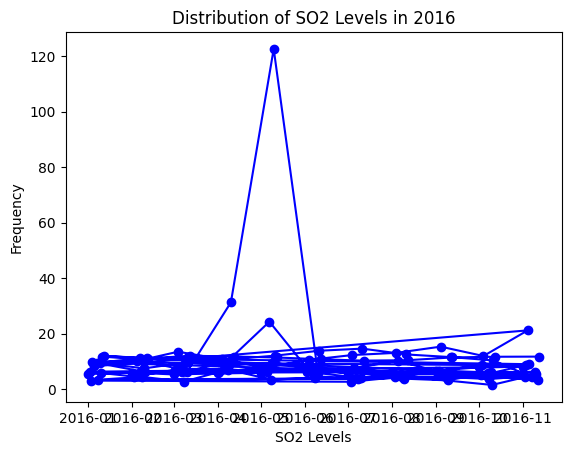

In [87]:
## Data Analysis and Visualization
import matplotlib.pyplot as plt
plt.plot( data_2016['From Date'], data_2016['SO2'], marker='o', linestyle='-', color='b')
plt.title('Distribution of SO2 Levels in 2016')
plt.xlabel('SO2 Levels')
plt.ylabel('Frequency')
plt.show()    
